# Initial Sentiment Backtest

Strategy: **High Sentiment Equal Weight Strategy**

This notebook evaluates a simple long-only sentiment strategy using the offline `daily_sentiment` table. It does not call Groq and does not use the frontend/dashboard. The result is an initial research backtest only, not investment advice.


In [1]:
from pathlib import Path
import json
import sqlite3
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))

from app.backtest.strategies import BacktestConfig, run_high_sentiment_equal_weight_strategy

DB_PATH = PROJECT_ROOT / "backend" / "data" / "twstock_sentiment.db"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = BacktestConfig(
    top_n=5,
    signal_column="sentiment_ma5",
    rebalance_frequency="W-FRI",
    benchmark="0050",
    transaction_cost=0.0,
    signal_lookback_days=20,
)


## Load Data

The strategy uses `daily_sentiment` as the signal source and `stock_prices` for strategy and benchmark returns.


In [2]:
with sqlite3.connect(DB_PATH) as conn:
    daily_sentiment = pd.read_sql_query("SELECT * FROM daily_sentiment ORDER BY target, trading_date", conn)
    stock_prices = pd.read_sql_query("SELECT * FROM stock_prices ORDER BY stock_id, date", conn)
    latest_db_result = pd.read_sql_query(
        "SELECT id, strategy_name, config, start_date, end_date, metrics, created_at FROM backtest_results ORDER BY id DESC LIMIT 1",
        conn,
    )

print(f"daily_sentiment rows: {len(daily_sentiment):,}")
print(f"stock_prices rows: {len(stock_prices):,}")
print(f"latest backtest_results rows loaded: {len(latest_db_result):,}")
display(daily_sentiment.head())


daily_sentiment rows: 46
stock_prices rows: 2,687
latest backtest_results rows loaded: 1


,target,trading_date,news_count,sentiment_avg,sentiment_sum,positive_count,neutral_count,negative_count,positive_ratio,negative_ratio,avg_confidence,sentiment_ma3,sentiment_ma5,sentiment_ma20
0,0050,2026-04-29,11,-0.209091,-2.3,1,6,4,0.090909,0.363636,0.809091,-0.209091,-0.209091,-0.209091
1,0050,2026-04-30,20,-0.065000,-1.3,5,8,7,0.250000,0.350000,0.815000,-0.137045,-0.137045,-0.137045
2,0050,2026-05-04,27,0.540741,14.6,19,6,2,0.703704,0.074074,0.837037,0.088883,0.088883,0.088883
3,0050,2026-05-05,20,0.160000,3.2,6,12,2,0.300000,0.100000,0.800000,0.211914,0.106662,0.106662
4,0050,2026-05-06,17,0.529412,9.0,12,4,1,0.705882,0.058824,0.811765,0.410051,0.191212,0.191212


## Run Strategy

Rules:

1. Use `daily_sentiment` as signals.
2. Rank by `sentiment_ma5` with `sentiment_avg` fallback inside the strategy implementation.
3. Rebalance weekly on the last available trading date of each `W-FRI` period.
4. Hold the top 5 targets by signal.
5. Equal weight, long only.
6. Benchmark is 0050.
7. Transaction cost parameter is present and set to 0 for this first version.


In [3]:
equity, positions, metrics = run_high_sentiment_equal_weight_strategy(daily_sentiment, stock_prices, CONFIG)
metrics_df = pd.DataFrame([
    {"portfolio": "strategy", **metrics["strategy"]},
    {"portfolio": "benchmark_0050", **metrics["benchmark"]},
])

equity.to_csv(TABLE_DIR / "backtest_equity_curve.csv", index=False, encoding="utf-8-sig")
positions.to_csv(TABLE_DIR / "backtest_positions.csv", index=False, encoding="utf-8-sig")
metrics_df.to_csv(TABLE_DIR / "backtest_metrics.csv", index=False, encoding="utf-8-sig")

display(metrics_df)
display(positions.head(20))


,portfolio,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,win_rate,number_of_rebalances
0,strategy,0.143572,6.305842,0.410789,15.350549,-0.062942,0.529412,3
1,benchmark_0050,0.072176,1.809650,0.269534,6.713991,-0.053224,0.352941,0


,rebalance_date,effective_date,target,weight,signal_value,rank,close_on_rebalance
0,2026-04-30,2026-05-04,2303,0.25,0.000000,1,77.300003
1,2026-04-30,2026-05-04,2547,0.25,0.000000,2,10.350000
2,2026-04-30,2026-05-04,3711,0.25,0.000000,3,478.000000
3,2026-04-30,2026-05-04,2330,0.25,-0.137143,4,2135.000000
4,2026-05-08,2026-05-11,2059,0.20,0.800000,1,5320.000000
5,2026-05-08,2026-05-11,2303,0.20,0.350000,2,91.300003
6,2026-05-08,2026-05-11,2454,0.20,0.320000,3,3630.000000
7,2026-05-08,2026-05-11,2330,0.20,0.258099,4,2290.000000
8,2026-05-08,2026-05-11,2347,0.20,0.000000,5,82.199997
9,2026-05-15,2026-05-18,2059,0.20,0.800000,1,4860.000000


## Equity Curve


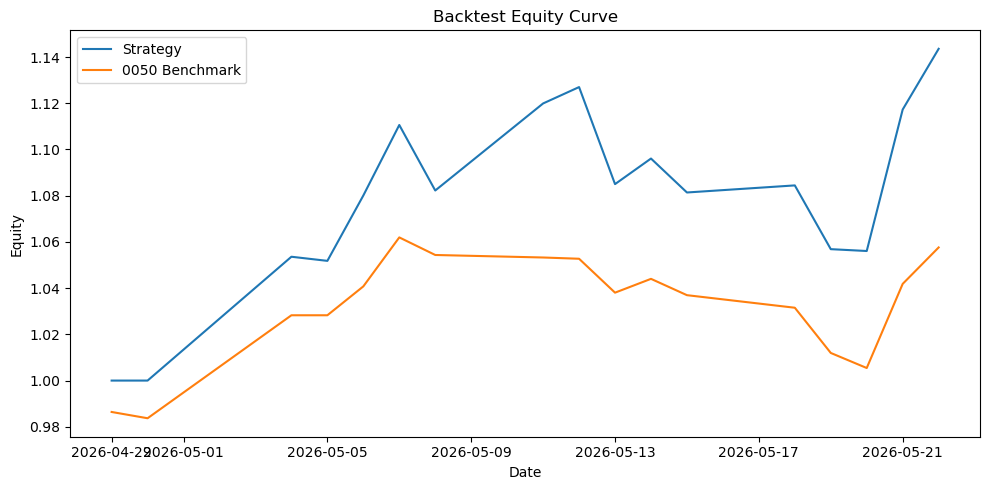

In [4]:
plot_df = equity.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_df["date"], plot_df["strategy_equity"], label="Strategy")
ax.plot(plot_df["date"], plot_df["benchmark_equity"], label="0050 Benchmark")
ax.set_title("Backtest Equity Curve")
ax.set_xlabel("Date")
ax.set_ylabel("Equity")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "backtest_equity_curve.png", dpi=160)
plt.show()


## Drawdown


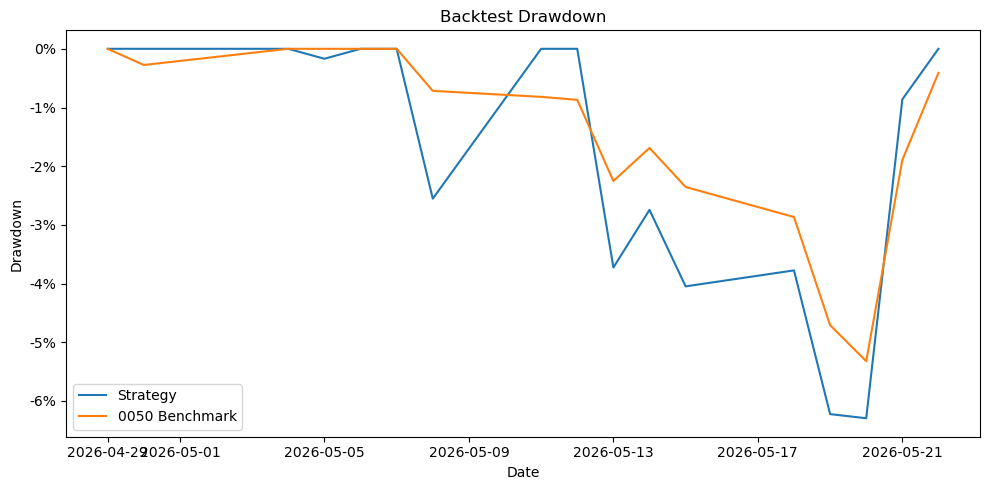

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_df["date"], plot_df["strategy_drawdown"], label="Strategy")
ax.plot(plot_df["date"], plot_df["benchmark_drawdown"], label="0050 Benchmark")
ax.set_title("Backtest Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "backtest_drawdown.png", dpi=160)
plt.show()


## Saved Outputs


In [6]:
for path in [
    FIGURE_DIR / "backtest_equity_curve.png",
    FIGURE_DIR / "backtest_drawdown.png",
    TABLE_DIR / "backtest_metrics.csv",
    TABLE_DIR / "backtest_equity_curve.csv",
    TABLE_DIR / "backtest_positions.csv",
]:
    print(f"{path}: {path.exists()} ({path.stat().st_size if path.exists() else 0} bytes)")


C:\python_data_analysis_final\outputs\figures\backtest_equity_curve.png: True (82673 bytes)
C:\python_data_analysis_final\outputs\figures\backtest_drawdown.png: True (83186 bytes)
C:\python_data_analysis_final\outputs\tables\backtest_metrics.csv: True (385 bytes)
C:\python_data_analysis_final\outputs\tables\backtest_equity_curve.csv: True (2118 bytes)
C:\python_data_analysis_final\outputs\tables\backtest_positions.csv: True (821 bytes)


## Database Result

`backend/scripts/run_backtest.py` writes the production-style result into `backtest_results`. The latest row is shown below.


In [7]:
if latest_db_result.empty:
    display(Markdown("No `backtest_results` row found. Run `backend/scripts/run_backtest.py` to persist one."))
else:
    display(latest_db_result)
    latest_metrics = json.loads(latest_db_result.loc[0, "metrics"])
    display(pd.DataFrame([
        {"portfolio": "strategy", **latest_metrics["strategy"]},
        {"portfolio": "benchmark_0050", **latest_metrics["benchmark"]},
    ]))


,id,strategy_name,config,start_date,end_date,metrics,created_at
0,1,High Sentiment Equal Weight Strategy,"{""top_n"": 5, ""signal_column"": ""sentiment_ma5"",...",2026-04-29,2026-05-22,"{""strategy"": {""total_return"": 0.14357188924197...",2026-05-22T15:17:26+00:00


,portfolio,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,win_rate,number_of_rebalances
0,strategy,0.143572,6.305842,0.410789,15.350549,-0.062942,0.529412,3
1,benchmark_0050,0.072176,1.809650,0.269534,6.713991,-0.053224,0.352941,0


## Preliminary Conclusion

The following notes are generated from the current backtest output.


In [8]:
def pct(value):
    return "n/a" if pd.isna(value) else f"{value:.2%}"

def num(value):
    return "n/a" if pd.isna(value) else f"{value:.2f}"

strategy = metrics["strategy"]
benchmark = metrics["benchmark"]
obs = []
obs.append("This is an initial backtest only and is not investment advice.")
obs.append(f"The tested period runs from {equity['date'].min()} to {equity['date'].max()}, so annualized metrics are highly sensitive to the short sample length.")
obs.append(f"The strategy total return is {pct(strategy['total_return'])}, compared with {pct(benchmark['total_return'])} for 0050 over the same curve window.")
obs.append(f"The strategy max drawdown is {pct(strategy['max_drawdown'])}, compared with {pct(benchmark['max_drawdown'])} for 0050.")
obs.append(f"The strategy rebalanced {int(strategy['number_of_rebalances'])} times. This is too few to infer stable performance.")
if strategy['total_return'] > benchmark['total_return']:
    obs.append("In this short sample, the strategy outperformed the 0050 benchmark on total return, but that does not prove the sentiment signal is durable.")
else:
    obs.append("In this short sample, the strategy did not outperform the 0050 benchmark; that should be reported directly rather than tuned away.")
obs.append("The previous sentiment-return notebook found weak correlations, so this backtest should be viewed as a sanity check rather than evidence of a deployable signal.")
obs.append("A stronger conclusion would require more historical data, out-of-sample validation, transaction costs, and tighter target coverage.")

for item in obs:
    display(Markdown(f"- {item}"))


- This is an initial backtest only and is not investment advice.

- The tested period runs from 2026-04-29 to 2026-05-22, so annualized metrics are highly sensitive to the short sample length.

- The strategy total return is 14.36%, compared with 7.22% for 0050 over the same curve window.

- The strategy max drawdown is -6.29%, compared with -5.32% for 0050.

- The strategy rebalanced 3 times. This is too few to infer stable performance.

- In this short sample, the strategy outperformed the 0050 benchmark on total return, but that does not prove the sentiment signal is durable.

- The previous sentiment-return notebook found weak correlations, so this backtest should be viewed as a sanity check rather than evidence of a deployable signal.

- A stronger conclusion would require more historical data, out-of-sample validation, transaction costs, and tighter target coverage.